In [25]:
import os
import shutil
import random
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR # เพิ่ม Scheduler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
# =========================================================
# STEP 0: กำหนด Random Seed เพื่อให้ผลลัพธ์เหมือนเดิมทุกครั้ง
# =========================================================
def set_seed(seed):
    """ฟังก์ชันสำหรับกำหนดค่า random seed ทั้งหมด"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# กำหนดค่า Seed ที่ต้องการ 
SEED_VALUE = 42
set_seed(SEED_VALUE)
print(f"Random seed set to {SEED_VALUE}")

Random seed set to 42


In [27]:
# =========================================================
# STEP 1: กำหนด Path และค่าต่างๆ (เหมือนเดิม)
# =========================================================

OUTPUT_DIR = r'C:\Users\Patth\Documents\train_val_test'
TRAIN_DIR = os.path.join(OUTPUT_DIR, 'train')
VAL_DIR = os.path.join(OUTPUT_DIR, 'val')
TEST_DIR = os.path.join(OUTPUT_DIR, 'test')

# =========================================================
# STEP 2: Data Augmentation และ Loaders (ฉบับปรับปรุง)
# =========================================================

# (1) สร้าง Transform สำหรับชุดข้อมูล Training ที่มีการ Augmentation 
#     เพื่อบังคับให้โมเดลเรียนรู้ลักษณะที่สำคัญจริงๆ ไม่ใช่แค่ท่องจำ
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # สุ่ม Crop ภาพ
    transforms.RandomHorizontalFlip(),                  # สุ่มกลับด้านซ้าย-ขวา
    transforms.RandomRotation(30),                      # สุ่มหมุนภาพ
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # สุ่มปรับสี
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# (2) Transform สำหรับ Validation/Test จะไม่มีการ Augmentation
#     เพื่อให้การวัดผลในแต่ละรอบมีความคงที่และเป็นมาตรฐานเดียวกัน
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# (3) สร้าง Datasets โดยใช้ Transforms ที่ถูกต้อง
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transforms)

# (4) สร้าง DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders created with new augmentation transforms.")

# =========================================================
# STEP 3: สร้างโมเดล, Loss, Optimizer 
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# โหลดโมเดล EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

# Loss function and Optimizer 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# *** Learning Rate Scheduler ***
# ช่วยปรับ learning rate ให้ลดลงอัตโนมัติเมื่อโมเดลเริ่มเรียนรู้ได้ช้าลง
# โดยจะลด lr ลง 10% (gamma=0.1) ทุกๆ 7 epochs (step_size=7)
scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

# =========================================================
# STEP 4: Training and Validation Loop 
# =========================================================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

def val_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

# เริ่มการเทรน
num_epochs = 15 # สามารถปรับได้ตามความเหมาะสม
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = val_one_epoch(model, val_loader, criterion, device)
    
    # *** ให้ Scheduler ทำงานหลังจากจบแต่ละ Epoch ***
    scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"Current Learning Rate: {scheduler.get_last_lr()[0]}") # แสดง lr ปัจจุบัน
    print("-" * 20)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

print("Finished Training")

C:\Users\Patth\anaconda3\envs\PyTorch\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Patth\anaconda3\envs\PyTorch\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DataLoaders created with new augmentation transforms.
Using device: cuda
Epoch 1/15


Validating: 100%|██████████| 65/65 [00:04<00:00, 13.30it/s]


Train Loss: 0.3265, Train Acc: 0.8987
Val Loss: 0.1376, Val Acc: 0.9633
Current Learning Rate: 0.001
--------------------
Epoch 2/15


Validating: 100%|██████████| 65/65 [00:04<00:00, 13.75it/s]


...

Train Loss: 0.0067, Train Acc: 0.9981
Val Loss: 0.0315, Val Acc: 0.9947
Current Learning Rate: 0.0001
--------------------
Epoch 14/15


Validating: 100%|██████████| 65/65 [00:04<00:00, 13.74it/s]


Train Loss: 0.0056, Train Acc: 0.9986
Val Loss: 0.0312, Val Acc: 0.9942
Current Learning Rate: 1e-05
--------------------
Epoch 15/15


Validating: 100%|██████████| 65/65 [00:04<00:00, 13.37it/s]

Train Loss: 0.0060, Train Acc: 0.9978
Val Loss: 0.0285, Val Acc: 0.9957
Current Learning Rate: 1e-05
--------------------
Finished Training



Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     1.0000    1.0000    1.0000       200
                     Pepper__bell___healthy     0.9966    0.9966    0.9966       296
                      Potato___Early_blight     1.0000    1.0000    1.0000       200
                       Potato___Late_blight     1.0000    1.0000    1.0000       200
                           Potato___healthy     1.0000    0.9667    0.9831        30
                      Tomato_Bacterial_spot     0.9977    0.9977    0.9977       426
                        Tomato_Early_blight     0.9900    0.9900    0.9900       200
                         Tomato_Late_blight     1.0000    1.0000    1.0000       382
                           Tomato_Leaf_Mold     1.0000    1.0000    1.0000       190
                  Tomato_Septoria_leaf_spot     0.9944    1.0000    0.9972       354
Tomato_Spider_mites_Two_spotted_spider_m

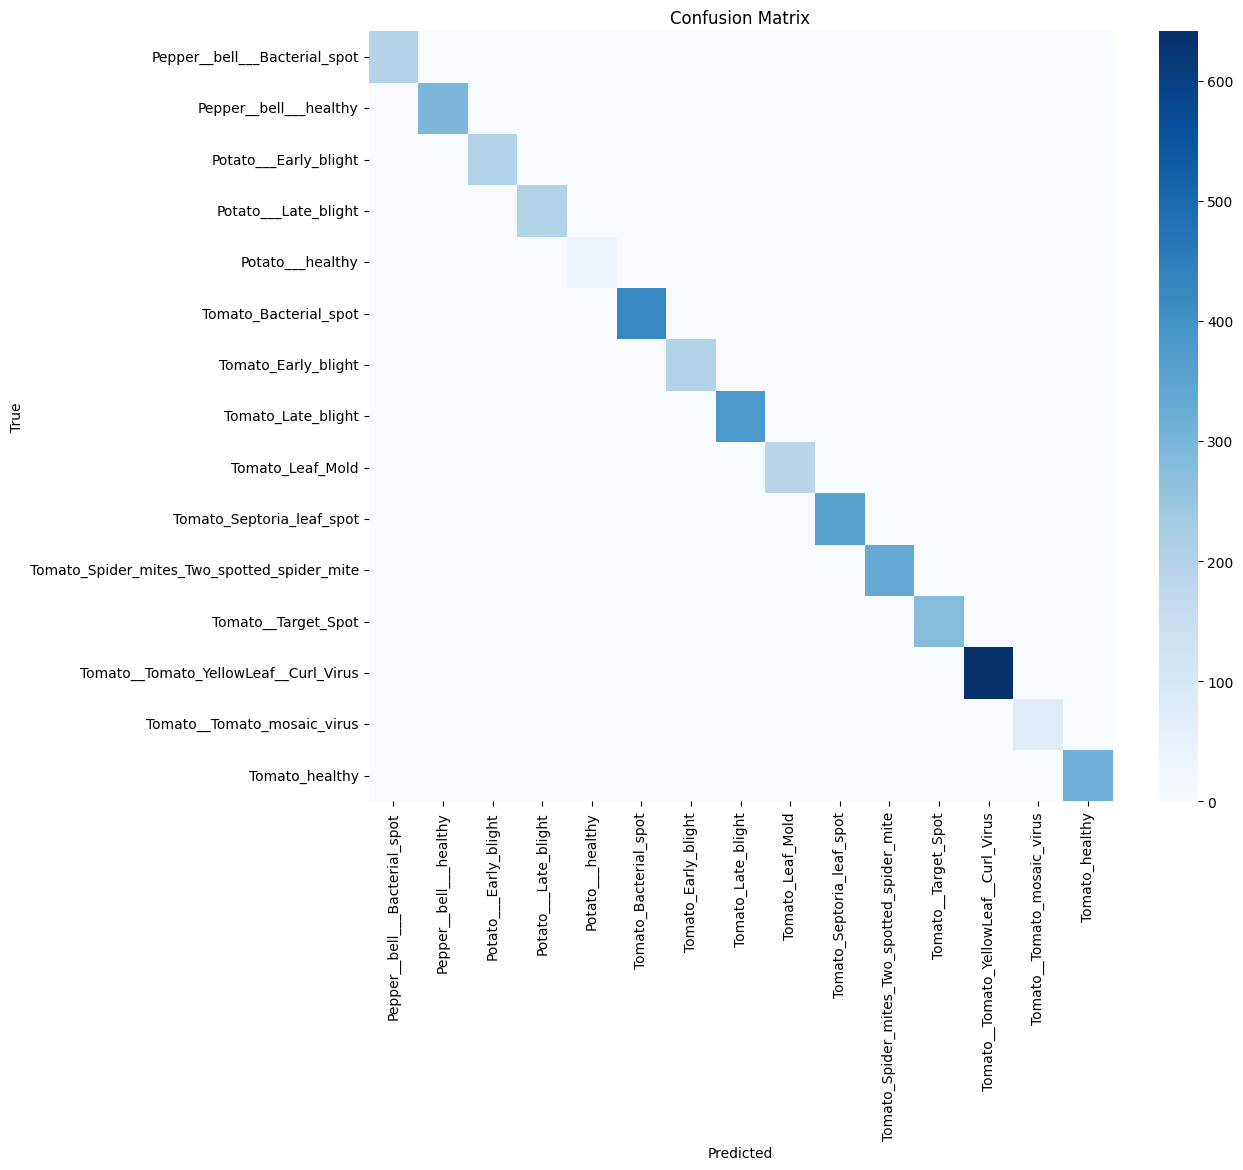

In [28]:
# =========================================================
# STEP 5: Evaluation on Test set
# =========================================================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

classes = train_dataset.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [29]:
# =========================================================
# STEP 6: บันทึกโมเดลและแสดงผล (เหมือนเดิม)
# =========================================================

MODEL_SAVE_PATH = r'C:\Users\Patth\Documents\efficientnet_b0_plant_disease_3.pth'
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to C:\Users\Patth\Documents\efficientnet_b0_plant_disease_3.pth
